# Fine-tuning U-Net architecture
Modèles basés sur l'architeture U-Net :
- U-Net avec encodeur ResNet34
- ResAttentionUNetPlusPlus
- EggSegmentationHVUNet

In [1]:
import os
import numpy as np
import torch
import torch.optim as optim
import pickle 
import time
import sys
import pandas as pd
import random

from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import segmentation_models_pytorch as smp
from pathlib import Path
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

# Importation des classes de dataset personnalisées
from utils.dataset_unet import RoboflowUNetDataset, EggHVDataset

# Importation des fonctions utilitaires
from utils.models_config import collate_fn, collate_fn_egg_hv, split_dataset, dataset_to_dict, save_validation_masks
from utils.segmentation_metrics import metrics_by_class
from utils.segmentation_visualization import plot_segmentation_comparison, save_validation_overlays
from utils.post_traitement import keep_largest_components, fill_holes, split_eggs
from utils.fonctions_de_perte import BCE_DiceLoss, BCE_DiceLoss_ignore, BCE_Dice_ContourLoss_ignore

# Importation des modèles U-Net personnalisés
from models.ResAttentionUNetPlusPlus import ResAttentionUNetPlusPlus
from models.EggSegmentationHVUNet import (EggSegmentationHVUNet, EggSegmentationHVLoss, postprocess_egg_instances)

/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reproductibilité du code

In [3]:
# Gestion de la classe 'ignore' :
# True  -> les pixels ignore sont exclus de la loss et des métriques
# False -> les pixels ignore sont considérés comme du fond
IGNORE = True

# Gestion du Conditional Metadata Embedding
is_cme = False

# Seed global pour la reproductibilité des résultats
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Déterminisme complet des opérations cuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### =========== Choix du modèle ===========

In [4]:
MODEL_NAME = "UNet" # UNet, AttentionUNet++ ou EggSegmentationHVUNet

### =========== Choix des données ===========

In [5]:
DATASET_NAME = "2classes"  # "3classes" ou "2classes" ou "oeufs"

### Importation et traitement des données

In [6]:
# -------- 1. Importation des images et annotations --------
DATASET_CONFIG = {
    "2classes": {"images": "../data/COCO/images/cavite", "annotations": "../data/COCO/labels/cavite/annotations_2_classes.json"},
    "3classes": {"images": "../data/COCO/images/cavite", "annotations": "../data/COCO/labels/cavite/annotations.json"},
    "oeufs": {"images": "../data/COCO/images/oeufs", "annotations": "../data/COCO/labels/oeufs/annotations.oeufs.json"},
}
images_dir = DATASET_CONFIG[DATASET_NAME]["images"]
annotations_json = DATASET_CONFIG[DATASET_NAME]["annotations"]

# ------- 2. Création des répertoires pour les masques prédits et les résultats des métriques --------
masks_dir = f"masks/eval/{MODEL_NAME}/{DATASET_NAME}"
results_dir = f"results/eval/{MODEL_NAME}/{DATASET_NAME}"
os.makedirs(masks_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# ------- 3. Importation du Data Frame avec les metadata --------
df = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# -------- 4. Préparation du dataset --------
# Transformation du dataset en dictionnaire et récupération des informations nécessaires pour l'entraînement et l'évaluation
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(df, annotations_json, images_dir)

# Gestion de la classe "Ignore Gonade" si présente dans le dataset
gonade_id = class_ids.index(next((cid for cid, name in categories.items() if name == "Gonade"), class_ids[0])) if ignore_category_id is not None else None

class_names = [categories[cid] for cid in class_ids]
ignore_mode = "pixels ignore exclus de la loss et des métriques" if IGNORE else "pixels ignore considérés comme fond"
print(f"Model : {MODEL_NAME}, Dataset : {DATASET_NAME}, classes={class_names}")
print(f"IGNORE={IGNORE} : {ignore_mode}")

Classes détectées (2) : {1: 'Cavite', 2: 'Gonade'}
Catégorie ignore détectée : 'ignore' (id=4)
Model : UNet, Dataset : 2classes, classes=['Cavite', 'Gonade']
IGNORE=True : pixels ignore exclus de la loss et des métriques


### Division des données

In [7]:
cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test = split_dataset(all_samples)

Nombre total d'images valides : 169
Échantillons train/val        : 145
Échantillons de test          : 24


### Définition création des modèles

In [11]:
def build_model():
    if MODEL_NAME == "EggSegmentationHVUNet":
        if DATASET_NAME != "oeufs":
            raise ValueError("EggSegmentationHVUNet nécessite DATASET_NAME='oeufs'")
        return EggSegmentationHVUNet(in_channels=nb_channels, encoder_weights="imagenet")
    
    if MODEL_NAME == "UNet":
        return smp.Unet(
            encoder_name="resnet34", encoder_weights="imagenet",
            in_channels=nb_channels, classes=num_classes, activation=None)
    
    if MODEL_NAME == "AttentionUNet++":
        return ResAttentionUNetPlusPlus(
            num_classes=num_classes, in_channels=nb_channels, encoder_weights="imagenet")

### Définition création du dataset

In [12]:
def build_dataset(samples, is_train=False):
    if MODEL_NAME == "EggSegmentationHVUNet":
        if DATASET_NAME != "oeufs":
                    raise ValueError("EggSegmentationHVUNet nécessite DATASET_NAME='oeufs'")
        if not class_ids:
            raise ValueError("Aucune catégorie COCO disponible pour EggSegmentationHVUNet")
        return EggHVDataset(
            samples=samples, image_size=IMAGE_SIZE, is_train=is_train,
            egg_category_id=class_ids[0],
        ), collate_fn_egg_hv
    
    dataset = RoboflowUNetDataset(
        samples=samples, image_dir=images_dir, df=df, image_size=IMAGE_SIZE,
        num_classes=num_classes,
        class_ids=class_ids,
        is_train=is_train,
        is_cme = is_cme,
        ignore_category_id=ignore_category_id, # ID de la classe "Ignore" si présente
        ignore_target_class_idx=gonade_id if IGNORE else None, # None => ignore est du fond
    )
    return dataset, collate_fn

### Hyperparamètres du modèle et initialisation

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil: {device}")

# ---- 1. Hyperparamètres ----
EPOCHS = 150
nb_channels = 3 + (pd.get_dummies(df["categorie"], dtype=int).shape[1] if is_cme and MODEL_NAME != "EggSegmentationHVUNet" else 0)
learning_rate = 1e-3
IMAGE_SIZE = (512, 512)  # Taille des images d'entrée pour le modèle

# ---- 2. Fonctions de perte ----
if MODEL_NAME == "EggSegmentationHVUNet":
    loss_fn = EggSegmentationHVLoss(mask_weight=1, hv_weight=2.0)
else:
    loss_fn = BCE_Dice_ContourLoss_ignore(bce_weight=0.5, dice_weight=0.5, contour_weight=0, ignore_index=-100)

# ---- 3. Early stopping config ----
early_stopping_patience = 15  # nombre d'epochs sans amélioration avant arrêt
early_stopping_min_delta = 1e-3  # amélioration minimale considérée comme significative
lr_patience = 6 # nombre d'epochs sans amélioration avant réduction du learning rate

# ---- 4. Cross validation k-folds ----
k_folds = 5
if DATASET_NAME == "oeufs":
    # Les œufs n'ont pas de catégories d'échographie : on groupe uniquement par poisson.
    kf = GroupKFold(n_splits=k_folds, shuffle=True, random_state=42)
else:
    # Pour les gonades, on groupe par catégories et par poisson
    kf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=42)

def get_cv_splits():
    if DATASET_NAME == "oeufs":
        return kf.split(cv_samples, groups=groups_train)
    return kf.split(cv_samples, cv_categories, groups=groups_train)

# ---- 5. Initialisation ----
fold_results = {}
fold_histories = {}
best_epochs = []

Utilisation de l'appareil: cuda


### Entrainement et validation du modèle
A lancer que si besoin de faire un nouvel entrainement.

In [ ]:
for fold, (train_idx, val_idx) in enumerate(get_cv_splits()):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    fold_start_time = time.time() # Initialisation temps d'execution du fold

    # Générateur dédié au shuffle du train_loader pour que l'ordre des batchs soit identique quel que soit le modèle comparé
    loader_g = torch.Generator()
    loader_g.manual_seed(SEED + fold)

    # -------------- 1. Création des jeux de données pour ce fold --------------
    train_samples = [cv_samples[i] for i in train_idx]
    val_samples = [cv_samples[i] for i in val_idx]

    # ------ 1.1 Création des datasets et dataloaders ------
    train_dataset, train_collate = build_dataset(train_samples, is_train=True)
    val_dataset, val_collate = build_dataset(val_samples)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=train_collate, generator=loader_g)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=val_collate)

    # ------ 1.2 Récupération des métadonnées de validation ------
    val_categories_fold = [sample['category'] for sample in val_samples] if DATASET_NAME != "oeufs" else []
    val_ops_fold = [int(sample['position']) for sample in val_samples] if DATASET_NAME != "oeufs" else []
    val_ops_ratio_fold = [float(sample['position_ratio']) for sample in val_samples] if DATASET_NAME != "oeufs" else []
    val_names_fold = [sample['image_info']['file_name'] for sample in val_samples]
    val_echelle_fold = [df.loc[df["image_id"] == name.split("_")[0], "echelle"].values[0] for name in val_names_fold]

    # -------------- 2. Réinitialisation complète du Modèle et Optimiseur --------------
    # Rend l'initialisation des poids reproductible d'un run à l'autre pour un même modèle
    torch.manual_seed(SEED + fold)
    torch.cuda.manual_seed_all(SEED + fold)

    # ----- 2.1 Choix du modèle -----
    model = build_model()

    # ------ 2.2 Optimiseur et Scheduler -----
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4) # Optimiseur AdamW avec regularisation L2 pour éviter l'overfitting
    # Scheduler pour réduire le learning rate si la validation loss ne s'améliore pas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=lr_patience)

    # ------ 2.3 Initialisation par fold ------
    # Dictionnaires pour sauvegarder les métriques et informations de l'entrainement et de la validation
    history = {'train_loss': [], 
               'val_loss': [], 
               'val_iou' : [],
               'val_iou_all' : [],
               'best_epochs': []
               }
    # Dictionnaire pour sauvegarder les métriques de la meilleure epoch
    best_epochs = {'iou_by_class': {},
                   'dice_by_class': {},
                   'precision_by_class': {},
                   'recall_by_class': {},
                   'diff_surface': {},
                   'category': val_categories_fold, # Catégories, position et nom de l'échantillon de val déjà fixés
                   'ops': val_ops_fold,
                   'ops_ratio': val_ops_ratio_fold,
                   'name': val_names_fold
                   }
    
    best_val_loss = float('inf')
    best_val_masks = []
    best_val_images = []
    idx_best_epoch = -1
    early_stopping_counter = 0

# --------------------------- BOUCLE D'ENTRAINEMENT ET DE VALIDATION ---------------------------
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        # Epoch courante : utilisée par le dataset pour dériver un seed d'augmentation déterministe et identique entre modèles comparés.
        if hasattr(train_dataset, "epoch"):
            train_dataset.epoch = epoch
        if hasattr(val_dataset, "epoch"):
            val_dataset.epoch = epoch
        
        # -------------- 3. Training --------------
        model.train()
        running_loss = 0.0
        running_count = 0
        for batch in train_loader:
            images = batch['image'].to(device, non_blocking=True)
            masks = batch['mask'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images) # 1 canal par classe
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            # Perte cumulée
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_count += batch_size

        # Calcul de la perte moyenne de l'epoch
        avg_train_loss = running_loss / running_count if running_count > 0 else 0.0

        # -------------- 4. Validation ----------------
        model.eval()

        # --- 4.1 Initialisation des métriques ---
        val_loss = 0.0
        val_count = 0.0

        epoch_intersection_by_class = torch.zeros(num_classes, device=device)
        epoch_union_by_class = torch.zeros(num_classes, device=device)

        epoch_iou_by_class_tensors = []
        epoch_dice_by_class_tensors = []
        epoch_precision_by_class_tensors = []
        epoch_recall_by_class_tensors = []
        epoch_diff_surf_tensors = []
        epoch_val_masks = []
        epoch_val_images = []

        val_sample_offset = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device, non_blocking=True)
                masks = batch['mask'].to(device, non_blocking=True)

                outputs = model(images)
                loss = loss_fn(outputs, masks)

                # Cumul de la perte et du nombre d'échantillons
                batch_size = images.size(0)
                val_loss += loss.item() * batch_size
                val_count += batch_size

                # Hauteur physique totale en cm
                echelle_batch = torch.tensor(val_echelle_fold[val_sample_offset:val_sample_offset + batch_size], device=device, dtype=torch.float32).view(-1, 1)
                val_sample_offset += batch_size

                # --- 4.2 Prédictions et post-traitement---
                probs = torch.sigmoid(outputs)

                if MODEL_NAME == "EggSegmentationHVUNet":
                    true = masks[:, :1] > 0.5
                    batch_pred_masks = []
                    batch_instance_labels = []
                    for output in outputs:
                        pred_mask, instance_labels = postprocess_egg_instances(output)
                        batch_pred_masks.append(torch.from_numpy(pred_mask))
                        batch_instance_labels.append(torch.from_numpy(instance_labels))
                    preds = torch.stack(batch_pred_masks).unsqueeze(1).to(device=device, dtype=torch.bool)
                    instance_labels_batch = torch.stack(batch_instance_labels)
                    display_pred_masks = instance_labels_batch
                else:
                    valid_mask = masks != -100
                    true = (masks > 0.5) & valid_mask
                    preds = (probs > 0.5) & valid_mask

                    # ------ 4.2.1 Post-traitement  -----
                    if DATASET_NAME == "oeufs":
                        instance_labels_batch = split_eggs(preds, min_distance=4, min_area=100, ouverture_size=3, ouverture_iterations=1)
                        preds = (instance_labels_batch > 0).unsqueeze(1)
                        display_pred_masks = instance_labels_batch
                    else:
                        # Post-traitement : cavite, gonades et intestin
                        if preds.shape[1] > 1:
                            preds = keep_largest_components(preds)
                            preds = fill_holes(preds)
                        preds &= valid_mask
                        display_pred_masks = preds

                file_names_batch = [
                    os.path.basename(path) for path in batch.get("image_path", batch.get("file_names", []))
                ]
                export_masks = instance_labels_batch if DATASET_NAME == "oeufs" else preds
                epoch_val_masks.extend(
                    (file_name, true_mask.cpu().clone(), export_mask.cpu().clone())
                    for file_name, true_mask, export_mask in zip(file_names_batch, true, export_masks)
                )
                epoch_val_images.extend(
                    (file_name, image.cpu().clone(), display_mask.cpu().clone())
                    for file_name, image, display_mask in zip(file_names_batch, images, display_pred_masks)
                )

                # ------ 4.2 Calcul des métriques -----
                intersection, union, iou_per_img, dice_per_img, precision_per_img, recall_per_img, diff_surface = metrics_by_class(
                    true, preds, echelle_batch, DATASET_NAME,
                    egg_instance_labels=instance_labels_batch if DATASET_NAME == "oeufs" else None,
                    egg_annotation_areas_px=batch["egg_annotation_areas_px"] if DATASET_NAME == "oeufs" else None,
                    # L'échelle couvre la hauteur du crop original (380 px), pas le canevas paddé 512 px.
                    image_height_px=[size[1] for size in batch["original_size"]],
                )

                # Cumul des métriques pour l'epoch
                epoch_iou_by_class_tensors.append(iou_per_img)
                epoch_dice_by_class_tensors.append(dice_per_img)
                epoch_precision_by_class_tensors.append(precision_per_img)
                epoch_recall_by_class_tensors.append(recall_per_img)
                epoch_intersection_by_class += intersection.sum(dim=0)
                epoch_union_by_class += union.sum(dim=0)
                epoch_diff_surf_tensors.append(diff_surface)

        # Transfer sur le CPU en fin d'epoch
        epoch_iou_by_class = torch.cat(epoch_iou_by_class_tensors).cpu().tolist()
        epoch_dice_by_class = torch.cat(epoch_dice_by_class_tensors).cpu().tolist()
        epoch_diff_surface = torch.cat(epoch_diff_surf_tensors).cpu().tolist()
        epoch_precision_by_class = torch.cat(epoch_precision_by_class_tensors).cpu().tolist()
        epoch_recall_by_class = torch.cat(epoch_recall_by_class_tensors).cpu().tolist()

        # Fin de la validation de l'epoch
        avg_val_loss = val_loss / val_count
        mean_val_iou = (epoch_intersection_by_class / (epoch_union_by_class + 1e-6)).mean().item()
        mean_val_iou_all = (epoch_intersection_by_class.sum() / (epoch_union_by_class.sum() + 1e-6)).item()

        scheduler.step(avg_val_loss) # Scheduler

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_iou'].append(mean_val_iou)
        history['val_iou_all'].append(mean_val_iou_all)
        
        # Early stopping + sauvegarde
        if avg_val_loss + early_stopping_min_delta < best_val_loss:
            best_val_loss = avg_val_loss
            best_val_masks = [
                (file_name, true_mask.clone(), pred_mask.clone())
                for file_name, true_mask, pred_mask in epoch_val_masks
            ]
            best_val_images = [
                (file_name, image.clone(), pred_mask.clone())
                for file_name, image, pred_mask in epoch_val_images
            ]
            os.makedirs("saves", exist_ok=True)
            torch.save(model.state_dict(), f"unet_finetuned_fold_{fold+1}_{MODEL_NAME}_{DATASET_NAME}.pth")
            early_stopping_counter = 0  # reset counter
            idx_best_epoch = epoch

            # Sauvegarde les métriques et infos de la meilleure epoch
            best_epochs['iou_by_class'] = {name: [row[idx] for row in epoch_iou_by_class] for idx, name in enumerate(class_names)}
            best_epochs["precision_by_class"] = {name: [row[idx] for row in epoch_precision_by_class] for idx, name in enumerate(class_names)}
            best_epochs["recall_by_class"] = {name: [row[idx] for row in epoch_recall_by_class] for idx, name in enumerate(class_names)}
            best_epochs["dice_by_class"] = {name: [row[idx] for row in epoch_dice_by_class] for idx, name in enumerate(class_names)}
            best_epochs['diff_surface'] = {name: [row[idx] for row in epoch_diff_surface] for idx, name in enumerate(class_names)}
            history['best_epochs'] = [idx_best_epoch]

        else:
            early_stopping_counter += 1

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch}/{EPOCHS} — train_loss: {avg_train_loss:.4f}, val_loss: {avg_val_loss:.4f}, val_iou: {mean_val_iou_all:.4f}, time: {epoch_time:.1f}s, lr : {optimizer.param_groups[0]['lr']:.2e}, early_stopping: {early_stopping_counter}/{early_stopping_patience}")

        if early_stopping_counter >= early_stopping_patience:
            print(f"EarlyStopping: arrêt après {early_stopping_counter} epochs sans amélioration (patience={early_stopping_patience}).")
            break
        
    # Résultats finaux
    print(f"Meilleur epoch (selon val_loss): {idx_best_epoch} avec val_loss={best_val_loss:.4f}")
    print(f"Modèle sauvegardé sous unet_finetuned_fold_{fold+1}_{MODEL_NAME}_{DATASET_NAME}.pth (dernier best)")
    save_validation_masks(masks_dir, best_val_masks, dataset_name=DATASET_NAME)
    save_validation_overlays(
        results_dir, best_val_images,
        dataset_name=DATASET_NAME, class_names=class_names
    )
    
    # Sauvegarde du temps d'execution
    fold_total_time = time.time() - fold_start_time
    history['fold_time_seconds'] = fold_total_time
    best_epochs["time"] = fold_total_time
    
    fold_results[f'fold_{fold+1}'] = best_epochs
    fold_histories[f'fold_{fold+1}'] = history

--- DEBUT DU FOLD 1/5 ---


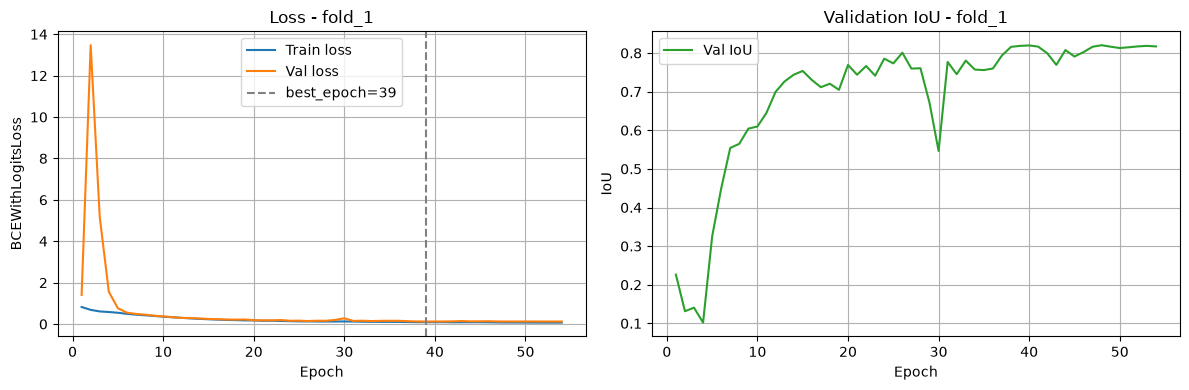

=== FOLD_1 ===
Train loss per epoch: [0.8226797228274139, 0.6841304001600846, 0.6082208032193391, 0.5812723424123681, 0.5441201178923897, 0.49240080325499824, 0.45314994324808533, 0.4217573593492093, 0.3913067283837692, 0.3557359542535699, 0.32710415332213694, 0.3002673677776171, 0.27321972237980885, 0.2489469491917154, 0.23104284613028817, 0.21200619106707366, 0.19681272506713868, 0.18928530293962229, 0.17731504336647366, 0.1730556729047195, 0.1571204283963079, 0.15805802734001823, 0.14848325576471247, 0.1376043016495912, 0.12846599538689074, 0.12559700297272725, 0.12225254359452621, 0.1198424074312915, 0.12169155024963876, 0.1247327533753022, 0.11903717232787091, 0.11158150991667871, 0.10660715336384981, 0.10433200954095177, 0.10394403040409088, 0.10237217934235282, 0.09483381315417912, 0.08923991141111955, 0.09134123565062233, 0.0886042427757512, 0.0895518131878065, 0.08247974825941998, 0.0878814811291902, 0.08649971251902373, 0.08723699605983237, 0.08290240466594696, 0.077715199278

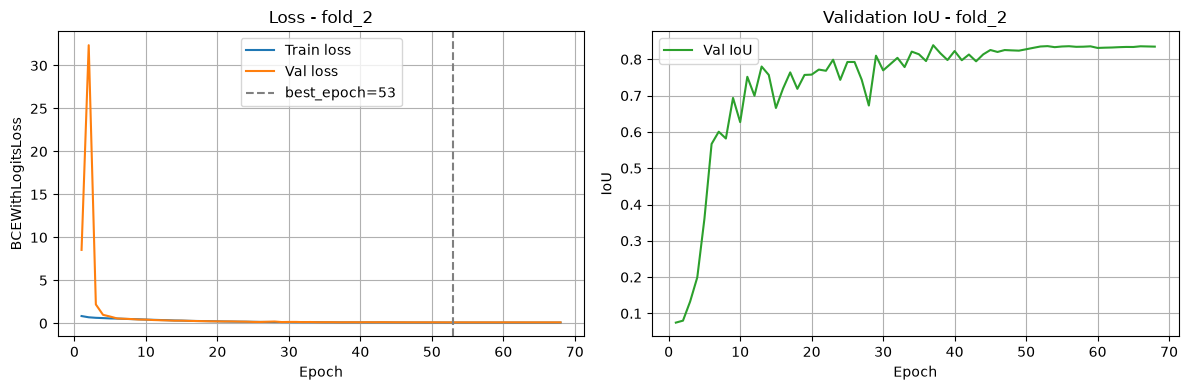

=== FOLD_2 ===
Train loss per epoch: [0.8396063360393556, 0.6948829736465063, 0.6351239783132178, 0.6026760482380533, 0.5629681297856518, 0.5481754566869165, 0.5136599989018888, 0.48466961302308953, 0.46446586623151076, 0.42868934915615964, 0.4031688840980204, 0.3780391835249387, 0.3551956820182311, 0.32427785946772647, 0.31015145651295656, 0.284437509938183, 0.26570231970558816, 0.2544048716369857, 0.24097104523426446, 0.2265560886798761, 0.209348729533008, 0.1958691402632966, 0.18761075052440676, 0.18110250955463475, 0.16952616065485865, 0.1557810342209971, 0.1507926431731281, 0.1433528465592963, 0.1388529159574427, 0.13114636569705784, 0.12424672044749953, 0.1252147202563082, 0.12089317381127268, 0.12015039199947292, 0.10990260579647163, 0.10909574803633568, 0.10242662139427967, 0.09958980124220888, 0.10083710956267822, 0.10066023545387463, 0.09563472236578281, 0.09880144824074884, 0.1005097607898916, 0.09492533297365548, 0.09255605916946362, 0.08891155048568025, 0.08615519533045271

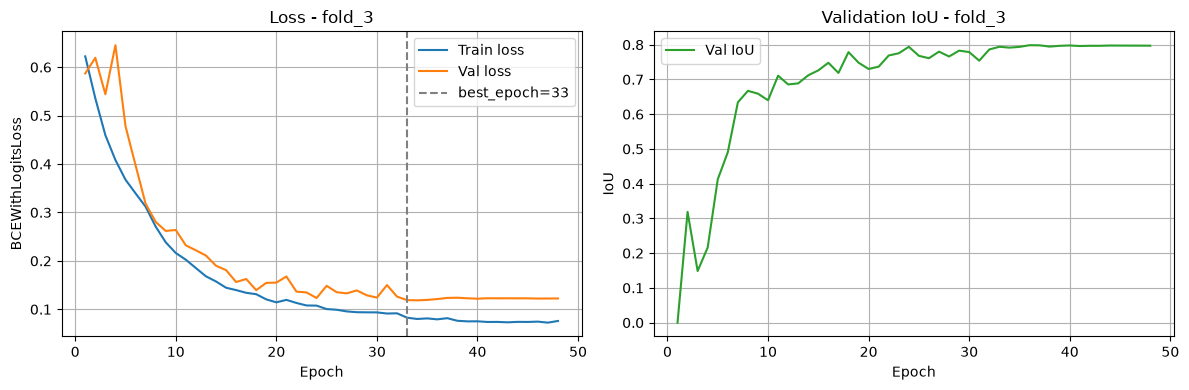

=== FOLD_3 ===
Train loss per epoch: [0.6222621634088713, 0.5357429940125038, 0.45957811741993343, 0.4081830834520274, 0.36767036442098944, 0.33947687827307604, 0.31191227559385626, 0.2708558214121851, 0.23841713574425927, 0.21624735100515957, 0.20239822515125933, 0.18515621999214435, 0.16814625777047257, 0.15748961321238814, 0.1445586522077692, 0.13966630193693885, 0.13410297138937588, 0.131178038387463, 0.12045869179840746, 0.11436757316877103, 0.11945489254491083, 0.11311155557632446, 0.10789838998482146, 0.10761277120688865, 0.10050184074146994, 0.0990842804312706, 0.09563875095597629, 0.09400438902706935, 0.09373896877313483, 0.09363818656781624, 0.09126525141041854, 0.09172376630635097, 0.08270720572307191, 0.0800238030737844, 0.08122276026627114, 0.07926239124659834, 0.0816834327475778, 0.07628697336747728, 0.07509249654309504, 0.07519207329585634, 0.07384450296903479, 0.07397764150438638, 0.07312068291779222, 0.07404863243472987, 0.07389692885094676, 0.07452952604869316, 0.0724

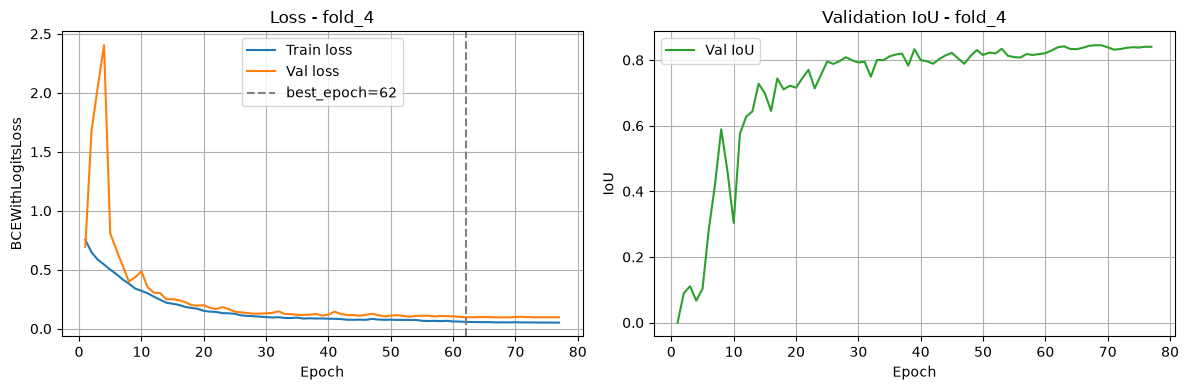

=== FOLD_4 ===
Train loss per epoch: [0.7553389398460715, 0.6473584715117756, 0.5854347709916595, 0.5440851276756352, 0.5008903848819244, 0.4620449744228624, 0.4172898367938832, 0.3820426779934484, 0.3403476127701947, 0.3215186015153543, 0.29999097876059705, 0.27186947653436255, 0.2454071964463617, 0.22010116253653142, 0.21177361408869425, 0.20186996179768163, 0.18506015990024957, 0.1760309746122768, 0.1690616654789346, 0.1512165396896183, 0.1447313039476036, 0.1419333624534118, 0.13209024676655093, 0.13057164058216617, 0.12587723575341395, 0.1133061637226333, 0.10840793820018442, 0.10619594602503328, 0.10218366993288709, 0.0984995533258487, 0.09532817752442808, 0.09723507428271139, 0.0914023308417736, 0.09031607821965829, 0.0942741757274693, 0.08589093450807099, 0.08831114729500225, 0.08640542651852991, 0.08672597303859189, 0.08443912061361167, 0.08396073131479768, 0.08165075266972566, 0.07604529396591024, 0.07548184425402911, 0.07662541183651003, 0.07507072459174018, 0.08282173310334

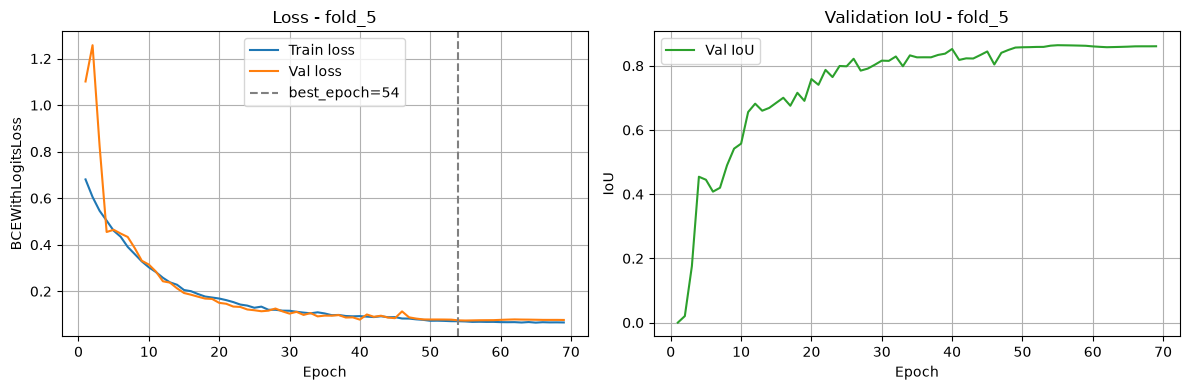

=== FOLD_5 ===
Train loss per epoch: [0.6807873326799144, 0.6053517678509588, 0.5458174213119175, 0.5036403161028157, 0.4604125051394753, 0.4343025487402211, 0.3906420552212259, 0.35965275090673693, 0.3283618476079858, 0.3031299712865249, 0.28279052739558014, 0.2580528572849605, 0.23837136211602583, 0.2282006888285927, 0.20549592660821003, 0.20025456392246743, 0.18803186909012173, 0.17745934504529703, 0.17316129363101462, 0.16885818165281544, 0.1620067211596862, 0.15360972738784293, 0.14296709765558657, 0.13846527765626493, 0.12917666318623916, 0.13397841064826302, 0.12058108863623246, 0.1204403852638991, 0.11671900729770246, 0.1162970307080642, 0.11195927417796592, 0.10831728642401488, 0.1053410340262496, 0.10962615181570468, 0.10469679605701696, 0.09734515878169434, 0.09826132862464242, 0.09370871607376181, 0.09237227219602336, 0.09323198173357093, 0.09097522173238837, 0.08912918800893037, 0.09258282080940579, 0.0885733337506004, 0.08895060795804728, 0.08301718157270681, 0.0826592074

In [11]:
# Boucle sur les 5 folds de fold_histories
for i, (fold_name, history) in enumerate(fold_histories.items()):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Récupération de la meilleure époque pour le fold courant (si disponible)
    current_best_epoch = history['best_epochs'][0] if 'best_epochs' in history and history['best_epochs'] else 0

    # 1. Loss plot (train vs val)
    epochs = range(1, len(history['train_loss']) + 1)
    axs[0].plot(epochs, history['train_loss'], label='Train loss')
    axs[0].plot(epochs, history['val_loss'], label='Val loss')
    if current_best_epoch > 0:
        axs[0].axvline(current_best_epoch, color='gray', linestyle='--', label=f'best_epoch={current_best_epoch}')
    axs[0].set_title(f'Loss - {fold_name}')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('BCEWithLogitsLoss')
    axs[0].legend()
    axs[0].grid(True)

    # 2. Val IoU plot
    iou_key = 'val_iou_all' if 'val_iou_all' in history else 'val_iou'
    axs[1].plot(epochs, history[iou_key], label='Val IoU', color='tab:green')
    axs[1].set_title(f'Validation IoU - {fold_name}')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('IoU')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Afichage des logs pour le fold courant
    print(f"=== {fold_name.upper()} ===")
    print('Train loss per epoch:', history['train_loss'])
    print('Val loss per epoch:  ', history['val_loss'])
    print('Val IoU per epoch:   ', history[iou_key])
    print('=' * 50 + '\n')

### Sauvegarde des résultats

In [12]:
file_path = f'results_{MODEL_NAME}_{DATASET_NAME}_CME.pkl'

# Sauvegarde de l'historique complet de tous les folds
with open(file_path, 'wb') as f:
    pickle.dump(fold_results, f)

## Résultats validation

In [54]:
# ------------ 1. Choix de l'image -------------
# Au choix : renseigner VIS_FOLD et VIS_INDEX ou directement VIS_FILENAME
VIS_FILENAME = '0004595_12.15.35_356430_2019.jpg'  # Exemple : '0006931_10.06.55_426711_2024.jpg'
VIS_FOLD = 1  # Numéro du fold
VIS_INDEX = 12  # Index de l'image dans le jeu de validation du fold

Nombre de folds disponibles : 5
Métriques pour 0004595_12.15.35_356430_2019.jpg — fold 3, index 6


,dice,iou,precision,recall,diff_surface (cm²)
classe,,,,,
Cavite,0.9336,0.8754,0.8855,0.9871,0.1562
Gonade,0.8629,0.7588,0.8556,0.8702,0.0171
Global,0.9044,0.8255,0.8735,0.9376,0.1733


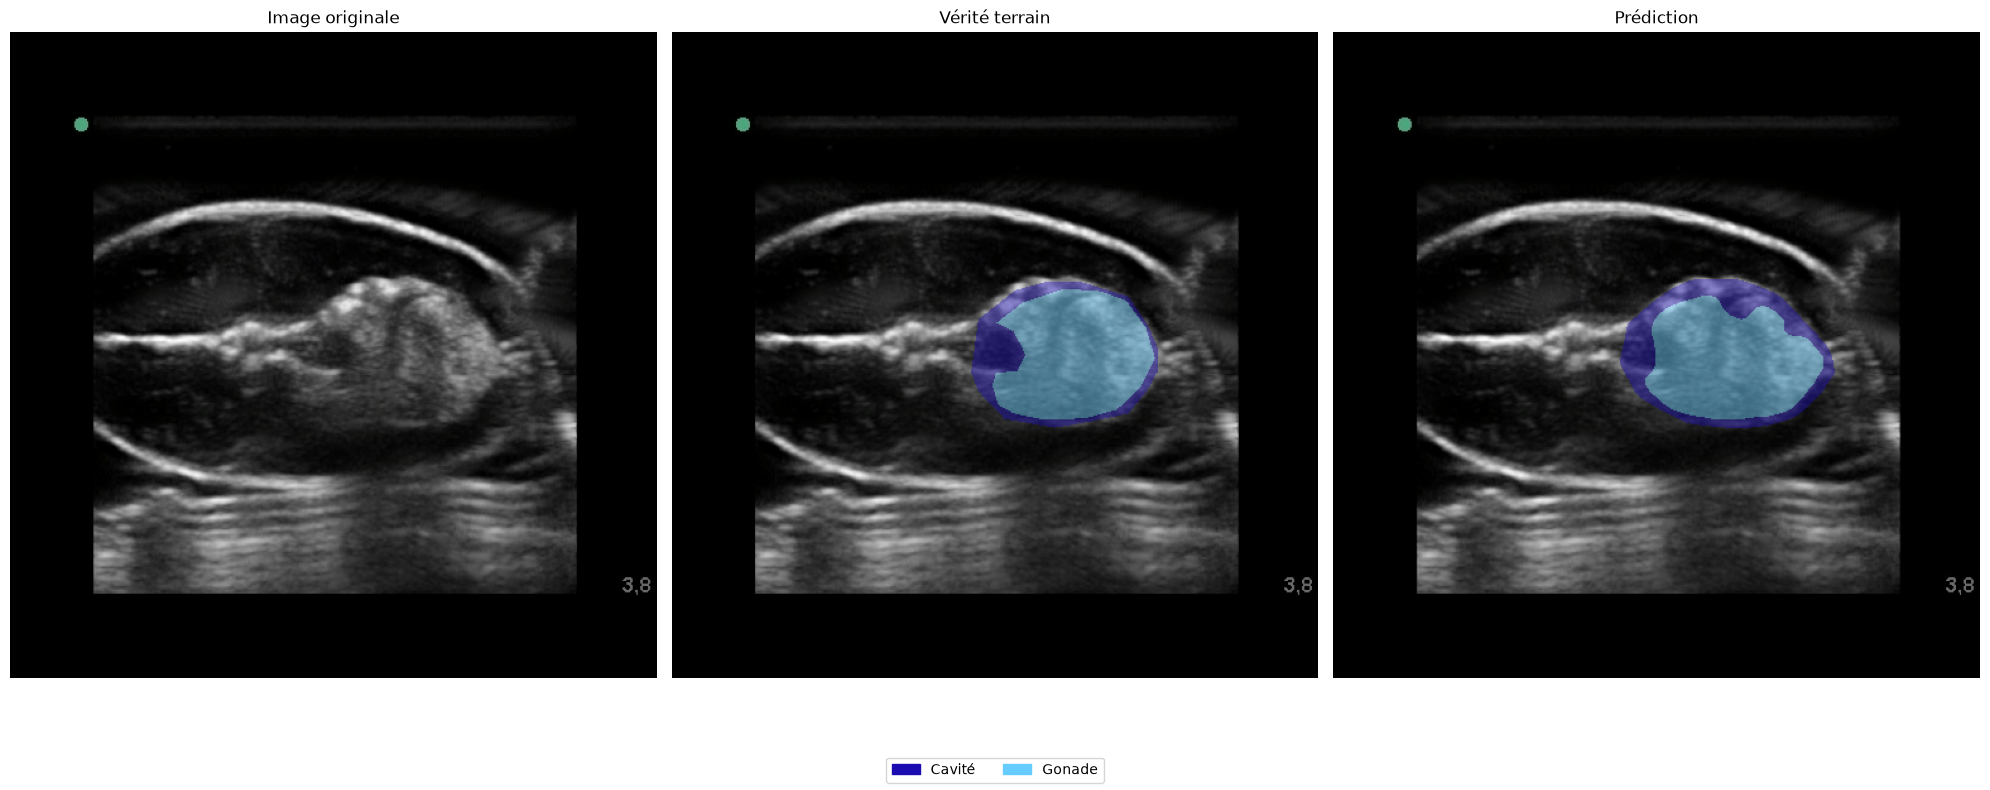

(<Figure size 2000x800 with 3 Axes>,
 array([<Axes: title={'center': 'Image originale'}>,
        <Axes: title={'center': 'Vérité terrain'}>,
        <Axes: title={'center': 'Prédiction'}>], dtype=object))

In [55]:
# ------------ 2. Reconstruction du fold de validation -------------
cv_splits = list(get_cv_splits())
print(f"Nombre de folds disponibles : {len(cv_splits)}")

if VIS_FILENAME is not None and str(VIS_FILENAME).strip():
    # Recherche exacte sur le nom du fichier, quel que soit le fold.
    requested_filename = Path(str(VIS_FILENAME).strip()).name
    filename_matches = []
    for fold_index, (_, val_indices_for_fold) in enumerate(cv_splits, start=1):
        val_indices_for_fold = np.asarray(val_indices_for_fold)
        for image_index, sample_index_for_match in enumerate(val_indices_for_fold):
            sample_for_match = cv_samples[int(sample_index_for_match)]
            sample_filename = Path(sample_for_match['image_info']['file_name']).name
            if sample_filename == requested_filename:
                filename_matches.append((fold_index, image_index, sample_index_for_match))

    if not filename_matches:
        raise FileNotFoundError(
            f"Fichier introuvable dans les folds de validation : {requested_filename}"
        )
    if len(filename_matches) > 1:
        matches = [(fold, index) for fold, index, _ in filename_matches]
        raise ValueError(
            f"Plusieurs correspondances trouvées pour {requested_filename} : {matches}"
        )

    VIS_FOLD, VIS_INDEX, sample_index = filename_matches[0]
    _, val_indices = cv_splits[VIS_FOLD - 1]
    val_indices = np.asarray(val_indices)
else:
    if not 1 <= VIS_FOLD <= len(cv_splits):
        raise ValueError(f"VIS_FOLD doit être compris entre 1 et {len(cv_splits)}.")

    _, val_indices = cv_splits[VIS_FOLD - 1]
    val_indices = np.asarray(val_indices)
    if not 0 <= VIS_INDEX < len(val_indices):
        raise IndexError(
            f"VIS_INDEX doit être compris entre 0 et {len(val_indices) - 1} "
            f"pour le fold {VIS_FOLD}."
        )

    sample_index = int(val_indices[VIS_INDEX])

# ------------ 3. Récupération des informations correspondantes -------------
sample = cv_samples[sample_index]
dataset_vis, _ = build_dataset([sample])
item = dataset_vis[0]
image_vis = item['image']
images = image_vis.unsqueeze(0).to(device)
masks = item['mask'].unsqueeze(0).to(device)
file_name = sample['image_info']['file_name']

# ------------ 4. Chargement du modèle et des probas -------------
checkpoint_path = Path(
    f"saves/unet_finetuned_fold_{VIS_FOLD}_{MODEL_NAME}_{DATASET_NAME}.pth"
)
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")

model_eval = build_model().to(device)
model_eval.load_state_dict(torch.load(checkpoint_path, map_location=device))
model_eval.eval()
with torch.inference_mode():
    logits = model_eval(images)

# ------------ 5. Prédictions et post-traitement -------------
if MODEL_NAME == "EggSegmentationHVUNet":
    pred_mask, instance_labels = postprocess_egg_instances(logits[0])
    true = masks[:, :1] > 0.5
    preds = torch.from_numpy(pred_mask)[None, None].to(device=device, dtype=torch.bool)
    prediction_to_plot = torch.from_numpy(instance_labels)
else:
    valid_mask = masks != -100
    true = (masks > 0.5) & valid_mask
    preds = (torch.sigmoid(logits) > 0.5) & valid_mask

    # Post-traitement et division : oeufs
    if DATASET_NAME == "oeufs":
        instance_labels = split_eggs(preds,
          min_distance=4,
          min_area=100,
          ouverture_size=3,
          ouverture_iterations=1
          )
        prediction_to_plot = instance_labels[0].cpu()
        preds = (instance_labels > 0).unsqueeze(1)

    else:
        # Post-traitement : cavite, gonades et intestin
        if preds.shape[1] > 1:
            preds = keep_largest_components(preds)
            preds = fill_holes(preds)
        preds &= valid_mask
        prediction_to_plot = preds[0].cpu()

# ----------- 5. Récupération de l'échelle -------------
scale_rows = df.loc[df["image_id"] == file_name.split("_")[0], "echelle"]
if scale_rows.empty:
    raise ValueError(f"Échelle introuvable pour {file_name}")
scale = float(scale_rows.iloc[0])
scale_tensor = torch.tensor([[scale]], device=device, dtype=torch.float32)

# ----------- 6. Calcul des métriques par classe -------------
intersection, union, iou, dice, precision, recall, diff_surface = metrics_by_class(
    true, preds, scale_tensor, DATASET_NAME,
    egg_instance_labels=instance_labels if DATASET_NAME == "oeufs" else None,
    egg_annotation_areas_px=[item["egg_annotation_areas_px"]] if DATASET_NAME == "oeufs" else None,
    # L'échelle couvre la hauteur du crop original (380 px), pas le canevas paddé 512 px.
    image_height_px=item["original_size"][1],
)
true_area = true.sum(dim=(2, 3)).float()
pred_area = preds.sum(dim=(2, 3)).float()
empty = (true_area + pred_area) == 0
for metric in (iou, dice, precision, recall):
    metric[empty] = 1.0

metric_rows = []
for class_idx, class_name in enumerate(class_names):
    metric_rows.append({
        "classe": class_name,
        "dice": dice[0, class_idx].item(),
        "iou": iou[0, class_idx].item(),
        "precision": precision[0, class_idx].item(),
        "recall": recall[0, class_idx].item(),
        "diff_surface": diff_surface[0, class_idx].item(),
    })

intersection_global = intersection.sum()
union_global = union.sum()
true_global = true_area.sum()
pred_global = pred_area.sum()
metric_rows.append({
    "classe": "Global",
    "dice": (2 * intersection_global / (true_global + pred_global)).item() if true_global + pred_global > 0 else 1.0,
    "iou": (intersection_global / union_global).item() if union_global > 0 else 1.0,
    "precision": (intersection_global / pred_global).item() if pred_global > 0 else float(true_global == 0),
    "recall": (intersection_global / true_global).item() if true_global > 0 else float(pred_global == 0),
    "diff_surface": diff_surface.sum().item(),
})

metrics_table = pd.DataFrame(metric_rows).set_index('classe')
surface_unit = "mm²" if DATASET_NAME == "oeufs" else "cm²"
metrics_table = metrics_table.rename(columns={"diff_surface": f"diff_surface ({surface_unit})"})
print(f"Métriques pour {file_name} — fold {VIS_FOLD}, index {VIS_INDEX}")
display(metrics_table.style.format(precision=4))

# ----------- 7. Affichage de l'image, du masque réel et de la prédiction ------
plot_segmentation_comparison(
    image_vis, true[0].cpu(), prediction_to_plot,
    is_eggs=DATASET_NAME == "oeufs", alpha=0.45,
)